In [1]:
import os
import sys
import pathlib
from pathlib import Path
import itertools as it
import functools as ft
import collections as clt
import json
import gzip
import pickle

In [2]:
prj_root = Path("__file__").absolute().parent.parent
if (t := str(prj_root)) not in sys.path:
    sys.path.append(t)

In [3]:
from util.obo_parser import Ontology, WangGOSim

In [4]:
from goatools.obo_parser import GODag
from tqdm import tqdm

In [5]:
import numpy as np
import pandas as pd
import dgl

/data0/shaojiangyi/miniconda3/envs/pytorch2.4/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
import ast
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import rcParams, rc
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.colors as mcolors
import matplotlib.cm as cm

In [7]:
# load term position depth
term_pos_path = Path("/data0/shaojiangyi/pprogo-flg-2/data/term_counts_with_position-111.pkl")
termpos_df = pd.read_pickle(term_pos_path)

In [8]:
termpos_df

,gos,counts,ic,position,maxdep,lgst
0,GO:0000015,8,13.340893,Deep,6,6
1,GO:0000109,35,11.211610,Deep,10,8
2,GO:0000110,7,13.533538,Deep,9,9
3,GO:0000111,2,15.340893,Deep,9,9
4,GO:0000112,8,13.340893,Deep,10,10
...,...,...,...,...,...,...
31558,GO:2001311,1,16.480585,Deep,8,8
31559,GO:2001313,1,16.480585,Deep,9,8
31560,GO:2001315,1,16.480585,Deep,9,9
31561,GO:2001316,2,15.480585,Deep,8,7


In [9]:
prot_link_path = "/data0/shaojiangyi/pprogo-flg-2/data-sp/swissprot_ppi.pkl"
protein_links = pd.read_pickle(prot_link_path)

In [29]:
protein_links

,index,proteins,accessions,sequences,annotations,interpros,orgs,exp_annotations,prop_annotations,cafa_target,target_proteins
0,239,11K_PAVHV,P0DJZ0;,MQNNTTGMDTKSLKNCGQPKAVCTHCKHSPPCPQPGCVTKRPPVPP...,"[GO:0030430|IDA, GO:0039526|IEA]",[],648237,[GO:0030430],"[GO:0030430, GO:0005575, GO:0033643, GO:004365...",False,[]
1,240,11S1_CARIL,B5KVH4;,MAKPILLSIYLCLIIVALFNGCLAQSGGRQQHKFGQCQLNRLDALE...,"[GO:0019863|IEA, GO:0045735|IC, GO:0048316|IEP...","[IPR022379, IPR006044, IPR006045, IPR014710, I...",32201,"[GO:0045735, GO:0048316, GO:0010431]","[GO:0021700, GO:0048731, GO:0048856, GO:000815...",False,[]
2,242,11S1_MACIN,C0HLR7;,LSTLNTHNLPLLRLVYLEREDLVAVHVDDLNNQANQLDQKLDGGLL...,"[GO:0019863|IDA, GO:0045735|IEA]",[IPR011051],60698,[GO:0019863],"[GO:0019865, GO:0044877, GO:0003674, GO:001986...",False,[]
3,244,11S2_SESIN,Q9XHP0;,MVAFKFLLALSLSLLVSAAIAQTREPRLTQGQQCRFQRISGAQPSL...,"[GO:0042735|NAS, GO:0045735|NAS, GO:0010431|IEP]","[IPR022379, IPR006044, IPR006045, IPR014710, I...",4182,[GO:0010431],"[GO:0021700, GO:0048731, GO:0048856, GO:000815...",False,[]
4,258,128UP_DROME,P32234; Q9V648;,MSTILEKISAIESEMARTQKNKATSAHLGLLKAKLAKLRRELISPK...,"[GO:0005737|IBA, GO:0005525|IDA, GO:0003924|IE...","[IPR012675, IPR045001, IPR031167, IPR006073, I...",7227,[GO:0005525],"[GO:0032561, GO:0097367, GO:0005525, GO:001900...",True,"[VLS_DROME, SMD1_DROME, UMPS_DROME, ASX_DROME,..."
...,...,...,...,...,...,...,...,...,...,...,...
79225,568337,ZZEF1_MOUSE,Q5SSH7; Q499C8; Q6ZQC5; Q8C710; Q8CI54;,MGNAPSNSSEDEAAAAGGEGWSPHQDWAADSGTTPGPGPAAAVLPS...,"[GO:0009986|IDA, GO:0098794|IDA, GO:0048786|ID...","[IPR004939, IPR011992, IPR002048, IPR008979, I...",10090,"[GO:0009986, GO:0098794, GO:0048786, GO:004520...","[GO:0048786, GO:0060255, GO:0009416, GO:000815...",True,"[MYH10_MOUSE, SOX1_MOUSE, ORC2_MOUSE, RNB3L_MO..."
79226,568338,ZZZ3_HUMAN,Q8IYH5; B7WPC6; Q6N004; Q6N070; Q8IYP0; Q8IYR1...,MAASRSTRVTRSTVGLNGLDESFCGRTLRNRSIAHPEEISSNSQVR...,"[GO:0140672|IDA, GO:0072686|IC, GO:0005730|IDA...","[IPR009057, IPR017930, IPR001005, IPR000433, I...",9606,"[GO:0140672, GO:0072686, GO:0005730, GO:000565...","[GO:0043226, GO:0051252, GO:0008150, GO:004885...",True,"[CHD1_HUMAN, IKZF5_HUMAN, CAND1_HUMAN, MS3L1_H..."
79227,568339,ZZZ3_MOUSE,Q6KAQ7; Q3TMK6; Q3V189;,MVGTCHSMAASRSTRVTRSTVGLNGLDESFCGRTLRNRSIAHPEEI...,"[GO:0140672|IDA, GO:0072686|IC, GO:0005730|ISO...","[IPR009057, IPR017930, IPR001005, IPR000433, I...",10090,"[GO:0140672, GO:0072686, GO:0051726, GO:005130...","[GO:0043226, GO:0000785, GO:0140535, GO:005172...",True,"[SIR6_MOUSE, EDEM2_MOUSE, MXI1_MOUSE, IBP4_MOU..."
79228,568348,Z_LASSJ,O73557;,MGNKQAKAPESKDSPRASLIPDATHLGPQFCKSCWFENKGLVECNN...,"[GO:0044220|IEA, GO:0020002|IEA, GO:0016020|IE...","[IPR024183, IPR038485, IPR003224]",11622,[GO:0046761],"[GO:0046753, GO:0051701, GO:0044419, GO:004400...",False,[]


In [10]:
go_path = "/data0/shaojiangyi/pprogo-flg-2/data/data-netgo/go.obo"
ont_obj = Ontology(go_path, with_rels=True)

In [11]:
# union_term_paths = [
#     "/data0/shaojiangyi/pprogo-flg-2/results/union_space_preds_only1/cc/test/union_go_terms.npy",
#     "/data0/shaojiangyi/pprogo-flg-2/results/union_space_preds_only1/mf/test/union_go_terms.npy",
#     "/data0/shaojiangyi/pprogo-flg-2/results/union_space_preds_only1/bp/test/union_go_terms.npy",
# ]

In [12]:
# union_term_lst = [np.load(p, allow_pickle=True) for p in union_term_paths]

In [13]:
ns = ["cc", "mf", "bp"]

In [14]:
ontology_lst = ["cellular_component", "molecular_function", "biological_process"]

In [15]:
term_space_path = "/data0/shaojiangyi/pprogo-flg-2/data-sp/namespace_terms.pkl"
with open(term_space_path, "rb") as h:
    namespace_terms = pickle.load(h)
union_term_lst = [namespace_terms[x] for x in ontology_lst]

In [16]:
union_termset = [set(m if isinstance(m, list) else m.tolist()) for m in union_term_lst]

In [17]:
# go_parents_lst = [{x: ont_obj.get_parents(x).intersection(union_termset[i])
#                    for x in xs}
#                    for i, xs in enumerate(union_term_lst)]

In [18]:
go_parents_lst = [{x: ont_obj.get_anchestors(x).intersection(union_termset[i])
                   for x in xs}
                   for i, xs in enumerate(union_term_lst)]

In [19]:
go_links = pd.concat([pd.DataFrame({"gos": list(d.keys()), "target_gos": list(d.values())}) for d in go_parents_lst])

In [20]:
go_links["target_gos"] = go_links["target_gos"].apply(lambda xs: list(xs))

In [21]:
go_to_prot = clt.defaultdict(list)
for p, gos in zip(protein_links["proteins"], protein_links["prop_annotations"]):
    for g in gos:
        go_to_prot[g].append(p)

In [22]:
go_links["target_proteins"] = go_links["gos"].apply(lambda x: go_to_prot.get(x, []))

In [23]:
go_links

,gos,target_gos,target_proteins
0,GO:0005575,[GO:0005575],"[11K_PAVHV, 13KDA_SCYCA, 13KDA_TRISC, 14310_AR..."
1,GO:0031261,"[GO:0005654, GO:0097373, GO:0043232, GO:000562...","[ABAP1_ARATH, CARM1_HUMAN, CDC18_SCHPO, CDC24_..."
2,GO:0052718,"[GO:0005575, GO:0140535, GO:0052718, GO:003299...","[TAD2_SCHPO, TAD2_YEAST, TAD3_SCHPO, TAD3_YEAST]"
3,GO:0048476,"[GO:0005575, GO:1905347, GO:0032991, GO:190249...","[EME1_SCHPO, HJC_PYRFU, MMS4_YEAST, MUS81_SCHP..."
4,GO:0140220,"[GO:0043657, GO:0018995, GO:0005575, GO:003364...","[AIFM1_DICDI, AMT1_DICDI, ARF1_DICDI, ARPC4_DI..."
...,...,...,...
21307,GO:0008627,"[GO:0007154, GO:0050896, GO:0050794, GO:000695...","[ARHG2_CANLF, BAD_MOUSE, BKRB2_MOUSE, CASP3_CA..."
21308,GO:2000166,"[GO:0016055, GO:0007154, GO:0050896, GO:004873...",[LRP6_MOUSE]
21309,GO:0034230,"[GO:0051604, GO:0044238, GO:0034641, GO:190156...","[CATL1_BOVIN, CBPE_RAT, NEC2_MOUSE]"
21310,GO:0060486,"[GO:0048731, GO:0009987, GO:0060541, GO:000815...","[GATA6_MOUSE, NFIB_MOUSE, NKX21_MOUSE, SUH_MOUSE]"


In [24]:
cmap_r_y_b = mcolors.LinearSegmentedColormap.from_list(
    "red_yellow_blue",
    ["red", "yellow", "blue"]
)
cmap_selected = plt.get_cmap('viridis_r')
# cmap_rdylbu = plt.get_cmap('Spectral')
# cmap_rdylbu = mcolors.LinearSegmentedColormap.from_list(
#     "rd_yl_bu",
#     ["#C91D1E", "#F1E01C", "#363EAC"]
# )
cmapname = "YlGnBu"
orig = plt.get_cmap(cmapname)
x = np.logspace(0, 1, 256)      # [1, 10]
x = (x - x.min()) / (x.max() - x.min())  # 归一化到 [0, 1]
# 映射到 [0.28, 1.0]
alpha = 0.28
x = alpha + x * (1.0 - alpha)

# 截掉最浅的 20%
new_cmap = mcolors.LinearSegmentedColormap.from_list(
    f"{cmapname}_trunc",
    orig(x)
)

# ---------- helpers ----------
def _to_collection(x):
    """
    Convert cell value to a Python collection (list/set/tuple) robustly.
    Accepts:
      - list/set/tuple already
      - empty / NaN
      - stringified python literal like "['A','B']" or "{'A','B'}"
      - comma-separated string like "A,B,C" (best-effort)
    Returns a list (possibly empty).
    """
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return []
    if isinstance(x, (list, tuple, set)):
        return list(x)
    if isinstance(x, str):
        s = x.strip()
        if s == "" or s.lower() in {"nan", "none", "null"}:
            return []
        # Try python literal eval first: "[]", "{}", "set(...)" won't parse, but "{...}" will.
        try:
            v = ast.literal_eval(s)
            if isinstance(v, (list, tuple, set)):
                return list(v)
        except Exception:
            pass
        # Fallback: treat as comma-separated
        if "," in s:
            return [t.strip() for t in s.split(",") if t.strip()]
        # Single token string
        return [s]
    # Unknown type -> best effort single item
    return [x]


def compute_counts(df: pd.DataFrame, col: str) -> pd.Series:
    """Return per-row counts of items in df[col] after robust parsing."""
    return df[col].apply(_to_collection).apply(len).astype(int)


def make_bins(counts: np.ndarray, strategy="log", max_bins=30):
    """
    Create bin edges for histogram.
    strategy:
      - "log": log-spaced edges for heavy-tailed degree distributions
      - "linear": integer-width bins
      - "fd": Freedman–Diaconis (continuous) then rounded
    """
    counts = np.asarray(counts, dtype=int)
    counts = counts[counts >= 0]
    if counts.size == 0:
        return np.array([0, 1])

    cmax = int(counts.max())
    if cmax <= 1:
        return np.array([0, 1, 2])  # minimal

    if strategy == "linear":
        # integer bins: 0,1,2,...,cmax+1
        return np.arange(0, cmax + 2)

    if strategy == "fd":
        # FD rule on integer data; ensure at least 2 bins
        q25, q75 = np.percentile(counts, [25, 75])
        iqr = max(q75 - q25, 1.0)
        bin_width = 2 * iqr * (counts.size ** (-1 / 3))
        bin_width = max(bin_width, 1.0)
        nbins = int(np.ceil((cmax - counts.min()) / bin_width))
        nbins = int(np.clip(nbins, 2, max_bins))
        edges = np.linspace(counts.min(), cmax + 1, nbins + 1)
        edges = np.unique(np.round(edges).astype(int))
        if edges.size < 2:
            edges = np.array([0, cmax + 1])
        return edges

    # default: log bins (good for long-tail)
    # Use integer-ish edges; include 0 as its own bin edge
    positive = counts[counts > 0]
    if positive.size == 0:
        return np.array([0, 1, 2])
    pmin = int(positive.min())
    pmax = int(positive.max())
    # Build log-spaced edges over [pmin, pmax+1]
    nbins = int(np.clip(np.round(np.log10(pmax + 1) * 10), 8, max_bins))
    edges_pos = np.unique(np.round(np.logspace(np.log10(max(pmin, 1)), np.log10(pmax + 1), nbins)).astype(int))
    edges_pos = edges_pos[edges_pos >= 1]
    # Ensure ends
    edges_pos = np.unique(np.r_[1, edges_pos, pmax + 1])
    # Prepend 0
    edges = np.unique(np.r_[0, edges_pos])
    return edges

def plot_nonzero_inset(ax, counts: pd.Series, bin_strategy="log",
                       width="40%", height="40%", loc="upper right",
                       bbox_to_anchor=(0.55,0.55,0.4,0.4)):
    """
    Draw an inset histogram excluding zero-count nodes.
    """
    nonzero = counts[counts > 0]
    if len(nonzero) == 0:
        return

    # ax_in = inset_axes(ax, width=width, height=height, loc=loc)
    ax_in = inset_axes(
            ax,
            width=width,
            height=height,
            bbox_to_anchor=bbox_to_anchor,
            bbox_transform=ax.transAxes,
            loc=loc,
            borderpad=0
        )

    arr = nonzero.to_numpy(dtype=int)
    edges = make_bins(arr, strategy=bin_strategy)

    hist, edges = np.histogram(arr, bins=edges)

    x = np.arange(len(hist))
    norm = mcolors.Normalize(vmin=0, vmax=len(edges)-1)
    # colors = cmap_r_y_b(norm(list(range(len(edges)-1))))
    colors = new_cmap(norm(list(range(len(edges)-1))))
    ax_in.bar(x, hist, color=colors)

    # 简化 inset 的视觉元素
    ax_in.set_title("count > 0", fontsize=18)
    ax_in.tick_params(axis='both', width=1.5, length=4, labelsize=14)
    ax_in.set_xlabel("")
    ax_in.set_ylabel("")

    # # x 轴标签只保留区间端点
    # labels = []
    # for i in range(len(edges) - 1):
    #     l, r = edges[i], edges[i + 1] - 1
    #     labels.append(f"{l}-{r}" if l != r else f"{l}")

    # ax_in.set_xticks(x)
    # ax_in.set_xticklabels(labels, rotation=45, ha="right", fontsize=7)
    ax_in.set_xticks([])

    # 边框更细，避免抢主图注意力
    for spine in ax_in.spines.values():
        spine.set_linewidth(1.)


def plot_binned_distribution(ax, counts: pd.Series, title: str = None, bin_strategy="log", show_zero_bar=True):
    """
    Plot histogram of counts with chosen binning strategy.
    X-axis: count bins, Y-axis: number of nodes.
    """
    arr = counts.to_numpy(dtype=int)
    edges = make_bins(arr, strategy=bin_strategy)

    # histogram
    hist, edges = np.histogram(arr, bins=edges)

    # Create human-readable bin labels
    labels = []
    for i in range(len(edges) - 1):
        left, right = edges[i], edges[i + 1] - 1
        if left == edges[i + 1] - 1:
            labels.append(f"{left}")
        else:
            labels.append(f"{left}-{right}")

    x = np.arange(len(hist))
    norm = mcolors.Normalize(vmin=0, vmax=len(edges)-1)
    # colors = cmap_r_y_b(norm(list(range(len(edges)-1))))
    colors = new_cmap(norm(list(range(len(edges)-1))))

    bars = ax.bar(x, hist, color=colors)

    sm = cm.ScalarMappable(norm=norm, cmap=new_cmap)
    sm.set_array([])

    cbar = plt.colorbar(sm, ax=ax, fraction=0.1, pad=0.02)

    n_bins = len(edges) - 1
    n_cbar_ticks = min(6, n_bins)

    tick_idx = np.linspace(0, n_bins - 1, n_cbar_ticks).astype(int)

    cbar.set_ticks(tick_idx)
    cbar.set_ticklabels([labels[i] for i in tick_idx], fontsize=12)
    ax.tick_params(width=1.5, length=4)

    cbar.ax.tick_params(labelsize=16)

    ax.set_title(title, fontsize=28, fontdict={"weight": "bold"})
    # ax.set_xlabel("Count bin")
    # ax.set_ylabel("#Nodes")

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right")

    for spine in ax.spines.values():
        spine.set_linewidth(1.5)  # 数值越大越粗

    # Optional: emphasize zero-count nodes info in title suffix
    if show_zero_bar:
        n_zero = int((arr == 0).sum())
        ax.text(0.99, 0.985, f"zero: {n_zero}", transform=ax.transAxes,
                ha="right", va="top", fontsize=20)

    # Improve layout
    ax.margins(x=0.01)


# ---------- main plotting ----------
def plot_three_distributions(protein_links: pd.DataFrame,
                             go_links: pd.DataFrame,
                             bin_strategy="log",
                             figsize=(20, 7),
                             save_path=None,
                             dpi=200):

    c_target_proteins = compute_counts(protein_links, "target_proteins")
    c_prop_ann = compute_counts(protein_links, "prop_annotations")
    c_target_gos = compute_counts(go_links, "target_gos")

    fig, axes = plt.subplots(1, 3, figsize=figsize, constrained_layout=True)

    # ---- Figure 1: Protein → target_proteins (with inset) ----
    plot_binned_distribution(
        axes[0],
        c_target_proteins,
        title="Protein → Protein",
        bin_strategy=bin_strategy
    )

    # 新增：non-zero inset
    plot_nonzero_inset(
        axes[0],
        c_target_proteins,
        bin_strategy=bin_strategy,
        width="100%",
        height="100%",
        loc="upper left",
        bbox_to_anchor=(0.25,0.15,0.7,0.7)
    )

    # ---- Figure 2 ----
    plot_binned_distribution(
        axes[1],
        c_prop_ann,
        title="Protein → GO",
        bin_strategy=bin_strategy
    )

    # ---- Figure 3 ----
    plot_binned_distribution(
        axes[2],
        c_target_gos,
        title="GO → GO",
        bin_strategy=bin_strategy
    )

    if isinstance(save_path, str):
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight")
    elif isinstance(save_path, list):
        for p in save_path:
            if p.endswith(".png"):
                fig.savefig(p, dpi=dpi, bbox_inches="tight")
            elif p.endswith(".svg"):
                fig.savefig(p)
            else:
                raise NotImplementedError(f"No supprot for the format of {os.path.basename(p)}")
    else:
        raise NotImplementedError("No support for this")
    return fig


In [25]:
def plot_four_distributions(protein_links: pd.DataFrame,
                            go_links: pd.DataFrame,
                            bin_strategy="log",
                            figsize=(30, 8),
                            save_path=None,
                            dpi=200):

    # Protein-side counts
    c_target_proteins = compute_counts(protein_links, "target_proteins")
    c_prop_ann = compute_counts(protein_links, "prop_annotations")

    # GO-side counts
    c_target_gos = compute_counts(go_links, "target_gos")
    c_go_target_proteins = compute_counts(go_links, "target_proteins")  # NEW

    fig, axes = plt.subplots(1, 4, figsize=figsize, constrained_layout=True)

    # ---- Figure 1: Protein → target_proteins (with inset) ----
    plot_binned_distribution(
        axes[0],
        c_target_proteins,
        title="Protein → Protein",
        bin_strategy=bin_strategy
    )

    # plot_nonzero_inset(
    #     axes[0],
    #     c_target_proteins,
    #     bin_strategy=bin_strategy,
    #     width="100%",
    #     height="100%",
    #     loc="upper left",
    #     bbox_to_anchor=(0.25, 0.15, 0.7, 0.7)
    # )

    # ---- Figure 2: Protein → prop_annotations ----
    plot_binned_distribution(
        axes[1],
        c_prop_ann,
        title="Protein → GO",
        bin_strategy=bin_strategy
    )

    # ---- Figure 3: GO → target_gos ----
    plot_binned_distribution(
        axes[2],
        c_target_gos,
        title="GO → GO",
        bin_strategy=bin_strategy
    )

    # ---- Figure 4: GO → target_proteins (NEW) ----
    plot_binned_distribution(
        axes[3],
        c_go_target_proteins,
        title="GO → Protein",
        bin_strategy=bin_strategy
    )

    if isinstance(save_path, str):
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight")
    elif isinstance(save_path, list):
        for p in save_path:
            if p.endswith(".png"):
                fig.savefig(p, dpi=dpi, bbox_inches="tight")
            elif p.endswith(".svg"):
                fig.savefig(p)
            else:
                raise NotImplementedError(f"No supprot for the format of {os.path.basename(p)}")
    else:
        raise NotImplementedError("No support for this")

    return fig


In [26]:
# # Example usage (assuming protein_links and go_links are already loaded DataFrames):
# fig = plot_three_distributions(protein_links, go_links, bin_strategy="log", 
#                                dpi=300,
#                                save_path="/data0/shaojiangyi/pprogo-flg-2/notebooks/figures/degree_distributions.png")
# plt.show()

In [27]:
# rcParams["xtick.direction"] = "in"
# rcParams["ytick.direction"] = "in"
# rcParams["font.family"] = "Arial"
# fig = plot_three_distributions(protein_links, go_links, bin_strategy="log", 
#                                dpi=300,
#                                save_path=["/data0/shaojiangyi/pprogo-flg-2/notebooks/figures/degree_distributions_v6.png",
#                                           "/data0/shaojiangyi/pprogo-flg-2/notebooks/figures/degree_distributions_v6.svg"]
#                                           )
# plt.show()

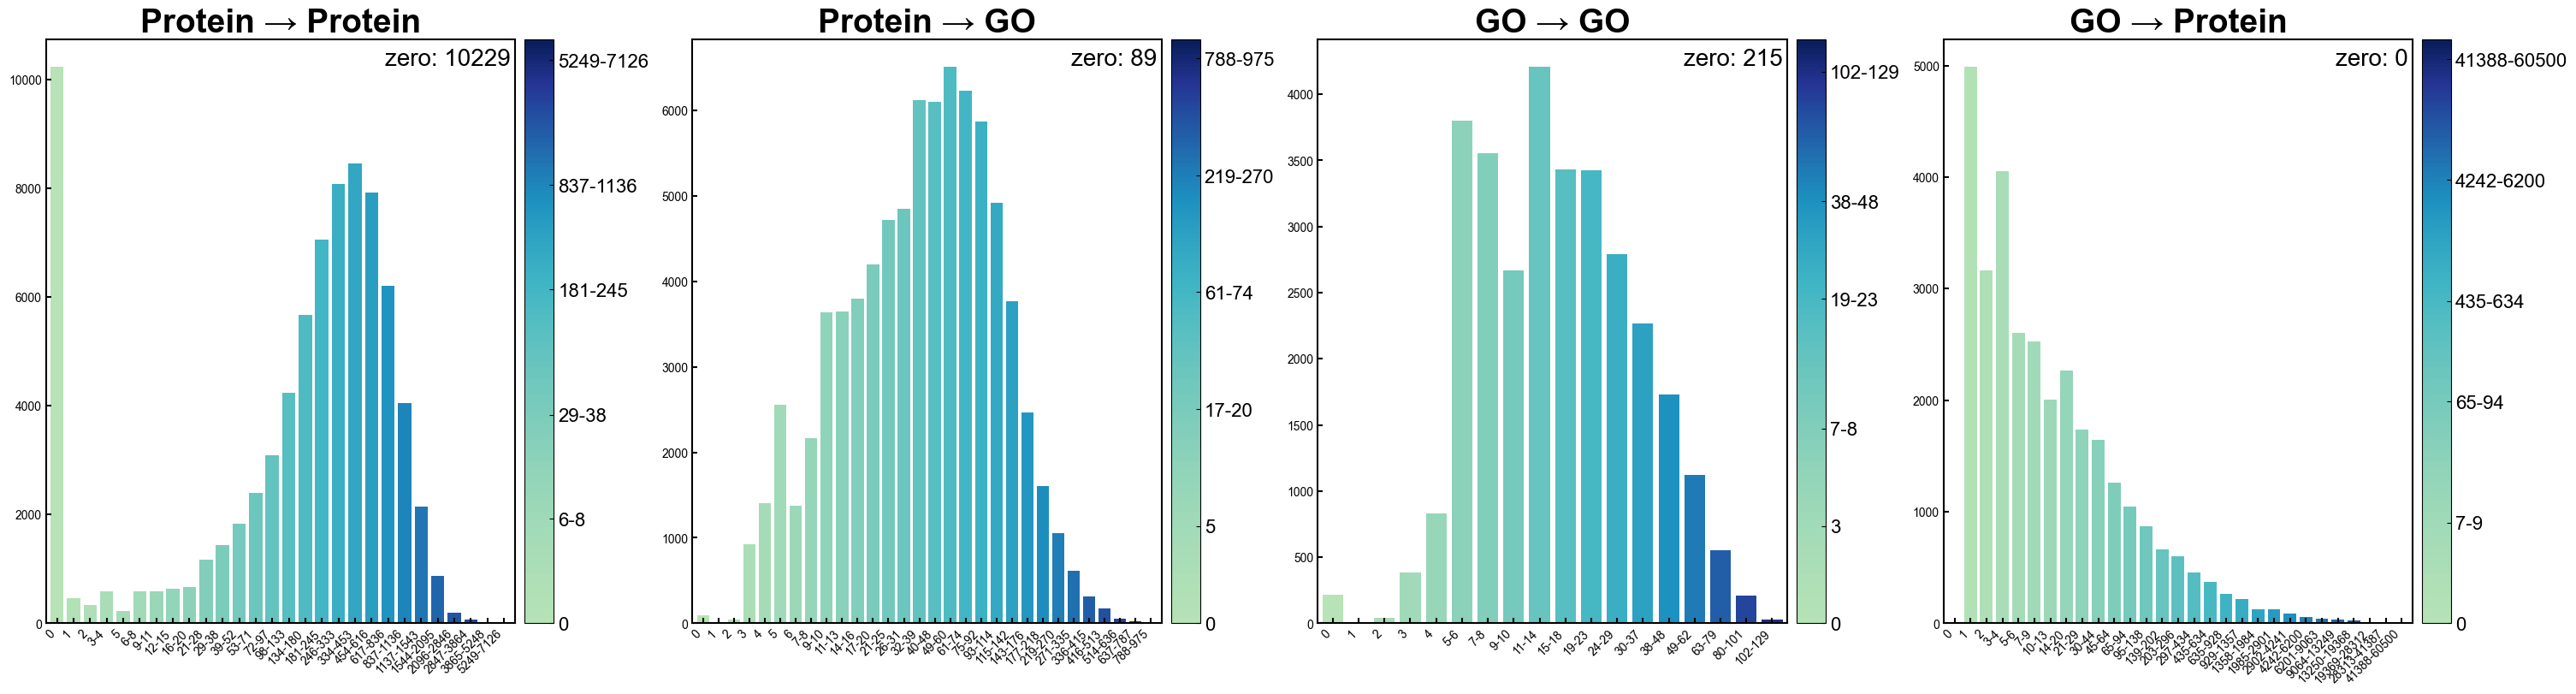

In [28]:
rcParams["xtick.direction"] = "in"
rcParams["ytick.direction"] = "in"
rcParams["font.family"] = "Arial"
fig = plot_four_distributions(protein_links, go_links, bin_strategy="log", 
                               dpi=300,
                               save_path=["/data0/shaojiangyi/pprogo-flg-2/notebooks/figures/swiss_prot_degree_4_dists_v6.png", "/data0/shaojiangyi/pprogo-flg-2/notebooks/figures/swiss_prot_degree_4_dists_v6.svg"]
                                )
plt.show()

In [18]:
ppi_dgl, info = dgl.load_graphs("/data0/shaojiangyi/pprogo-flg-2/data/ppi/ppi.dgl")

In [22]:
ppi_g = ppi_dgl[0]

In [13]:
dgg_pid = []
with open('/data0/shaojiangyi/pprogo-flg-2/data/ppi/ppi_pid_list.txt', 'r') as f:
    pid = f.readlines()
for p in pid:
    dgg_pid.append(p.removesuffix('\n')) 

In [14]:
len(dgg_pid)

189065

In [23]:
ppi_g

Graph(num_nodes=124073, num_edges=5159375,
      ndata_schemes={}
      edata_schemes={})

In [24]:
src, tgt = ppi_g.edges()